# MS Scoring — Melanie's Weighted Cluster Index

New classification method proposed by Melanie: instead of M2's binary rule cascade
(yes/no per CAS) or M1's graph-diffused labels, compute a **continuous weighted score**
per cluster for each recipe:

```
Raw_Score[recipe][cluster] = Σ (weight[CAS][cluster] × norm_Totalmenge[CAS])
Predicted_Cluster          = argmax(Raw_Score)
```

Weights come from `data/gold/Scoring Index_Beispielrechung.xlsx` (Melanie's expert matrix).
The notebook runs MS on all recipes, shows score profiles, then measures accuracy
against the panel ground truth and compares to M1/M2.


In [1]:
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from scripts.ms_scoring import (
    load_weight_matrix,
    load_recipes,
    compute_scores,
    normalize_scores,
    assign_clusters,
    map_to_panel,
    CLUSTER_COLS,
)

warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

# ── Paths ────────────────────────────────────────────────────────────────────
SCORING_XLSX = Path("../data/gold/Scoring Index_Beispielrechung.xlsx")
CSV_PATH     = Path("../data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv")
IGNORE_PATH  = Path("../data/gold/ignone_substances.csv")
VERK_XLSX    = "../data/gold/Verkostung Cluster KI vom 11_06_2026.xlsx"
PANEL_SCORE  = Path("../outputs/cluster_assignments_expert_seeded_all_strategies.xlsx")
OUT_XLSX     = Path("../outputs/scoring_ms_assessment.xlsx")

# ── Cluster name mapping: MS Excel names → panel GT names ────────────────────
# ⚠️  Confirm 'exotic' → 'dairy' and 'Outlayer' → 'Walderdbeere' with Melanie
#     before interpreting accuracy results as final.
MS_TO_PANEL: dict[str, str] = {
    "warm":       "warm",
    "Unpleasant": "unpleasant",
    "green":      "green",
    "floral":     "floral",
    "citrus":     "fruity",        # citrus/fruity overlap (isoamylacetat, banane)
    "exotic":     "dairy",         # ⚠️ uncertain — confirm with Melanie
    "Outlayer":   "Walderdbeere",  # outlier = Walderdbeere
}

EXPERT_CLUSTERS = ["warm", "floral", "Walderdbeere", "green", "dairy", "unpleasant", "fruity"]

# ── Colors for MS score bars ──────────────────────────────────────────────────
MS_COLORS = {
    "warm":       "#E63946",
    "Unpleasant": "#264653",
    "green":      "#2A9D8F",
    "floral":     "#F4A261",
    "citrus":     "#E76F51",
    "exotic":     "#E9C46A",
    "Outlayer":   "#9B59B6",
}

print("Config loaded. MS cluster → panel cluster mapping:")
for k, v in MS_TO_PANEL.items():
    print(f"  {k:12s} → {v}")


Config loaded. MS cluster → panel cluster mapping:
  warm         → warm
  Unpleasant   → unpleasant
  green        → green
  floral       → floral
  citrus       → fruity
  exotic       → dairy
  Outlayer     → Walderdbeere


## 2. Weight Matrix (from Melanie's Scoring Index)


In [2]:
weights = load_weight_matrix(SCORING_XLSX)
print(f"Weight matrix: {len(weights)} CAS × {len(CLUSTER_COLS)} clusters\n")

print("Non-zero ingredient counts per cluster:")
for col in CLUSTER_COLS:
    n = (weights[col] > 0).sum()
    print(f"  {col:12s}: {n:3d} ingredients")

print("\nTop-5 ingredients per cluster (by weight):")
for col in CLUSTER_COLS:
    top = weights[col].nlargest(5)
    top = top[top > 0]
    if len(top):
        print(f"\n  {col}:")
        for cas, w in top.items():
            print(f"    CAS {cas} → weight {w}")


Weight matrix: 224 CAS × 7 clusters

Non-zero ingredient counts per cluster:
  Unpleasant  :  23 ingredients
  warm        :  41 ingredients
  green       :  19 ingredients
  floral      :  28 ingredients
  citrus      :  11 ingredients
  exotic      :  12 ingredients
  Outlayer    :   7 ingredients

Top-5 ingredients per cluster (by weight):

  Unpleasant:
    CAS 64-18-6 → weight 20
    CAS 8008-79-5 → weight 15
    CAS 142-62-1 → weight 10
    CAS 142-62-1 → weight 8
    CAS 120-72-9 → weight 8

  warm:
    CAS 4940-11-8 → weight 20
    CAS 118-71-8 → weight 20
    CAS 765-70-8 → weight 18
    CAS 80-71-7 → weight 18
    CAS 3658-77-3 → weight 18

  green:
    CAS 6728-26-3 → weight 10
    CAS 66-25-1 → weight 9
    CAS 928-96-1 → weight 5
    CAS 111-27-3 → weight 5
    CAS 142-92-7 → weight 5

  floral:
    CAS 85-91-6 → weight 20
    CAS 8022-96-6 → weight 20
    CAS 134-20-3 → weight 15
    CAS 8031-03-6 → weight 15
    CAS 8016-38-4 → weight 15

  citrus:
    CAS 8008-57-9 → we

## 3. Score Computation


In [3]:
recipes_df = load_recipes(CSV_PATH, IGNORE_PATH)
all_recipes = recipes_df["Rez.-Nr."].unique()
print(f"Loaded {len(all_recipes)} recipes, {len(recipes_df)} ingredient rows after preprocessing.")

scores = compute_scores(recipes_df, weights)
print(f"\nScore matrix: {scores.shape[0]} recipes × {scores.shape[1]} clusters")

# How many CAS in recipe data overlap with weight matrix?
recipe_cas = set(recipes_df["CAS-Nr."].unique())
weight_cas = set(weights.index)
overlap = recipe_cas & weight_cas
print(f"\nCAS overlap: {len(overlap)} / {len(recipe_cas)} recipe CAS found in weight matrix")
print(f"  ({len(weight_cas)} CAS in weight matrix total)")

scores.head(10)


Loaded 130 recipes, 3366 ingredient rows after preprocessing.

Score matrix: 130 recipes × 7 clusters

CAS overlap: 223 / 230 recipe CAS found in weight matrix
  (223 CAS in weight matrix total)


,Unpleasant,warm,green,floral,citrus,exotic,Outlayer
Rez.-Nr.,,,,,,,
185.028,1.625564,0.756098,1.443581,0.476967,0.976130,1.039139,0.031116
185.043P,0.171039,0.312466,0.229839,0.139598,0.075362,0.086482,0.004865
185.044,0.170985,0.316086,0.229767,0.139554,0.075338,0.086455,0.004863
185.046,1.053045,4.636542,2.341847,1.803536,1.053045,1.053045,0.000000
185.086,0.305420,2.952337,0.743482,0.587123,0.312074,0.303059,0.000000
185.090P,0.174734,0.087577,0.081527,0.013257,0.013432,0.024295,0.000000
185.091,0.119908,0.495202,0.274875,0.173142,0.071409,0.071409,0.000000
185.133,0.116947,0.141715,0.357514,0.007000,0.002526,0.004211,0.000000
185.178HP,0.907007,3.750115,2.079789,1.311145,0.540535,0.540535,0.000000


## 4. Score Profiles (Normalized 0–1)

Horizontal bars show the flavor fingerprint per recipe.
A high single-cluster bar = unambiguous assignment.
Multiple bars of similar height = borderline recipe.

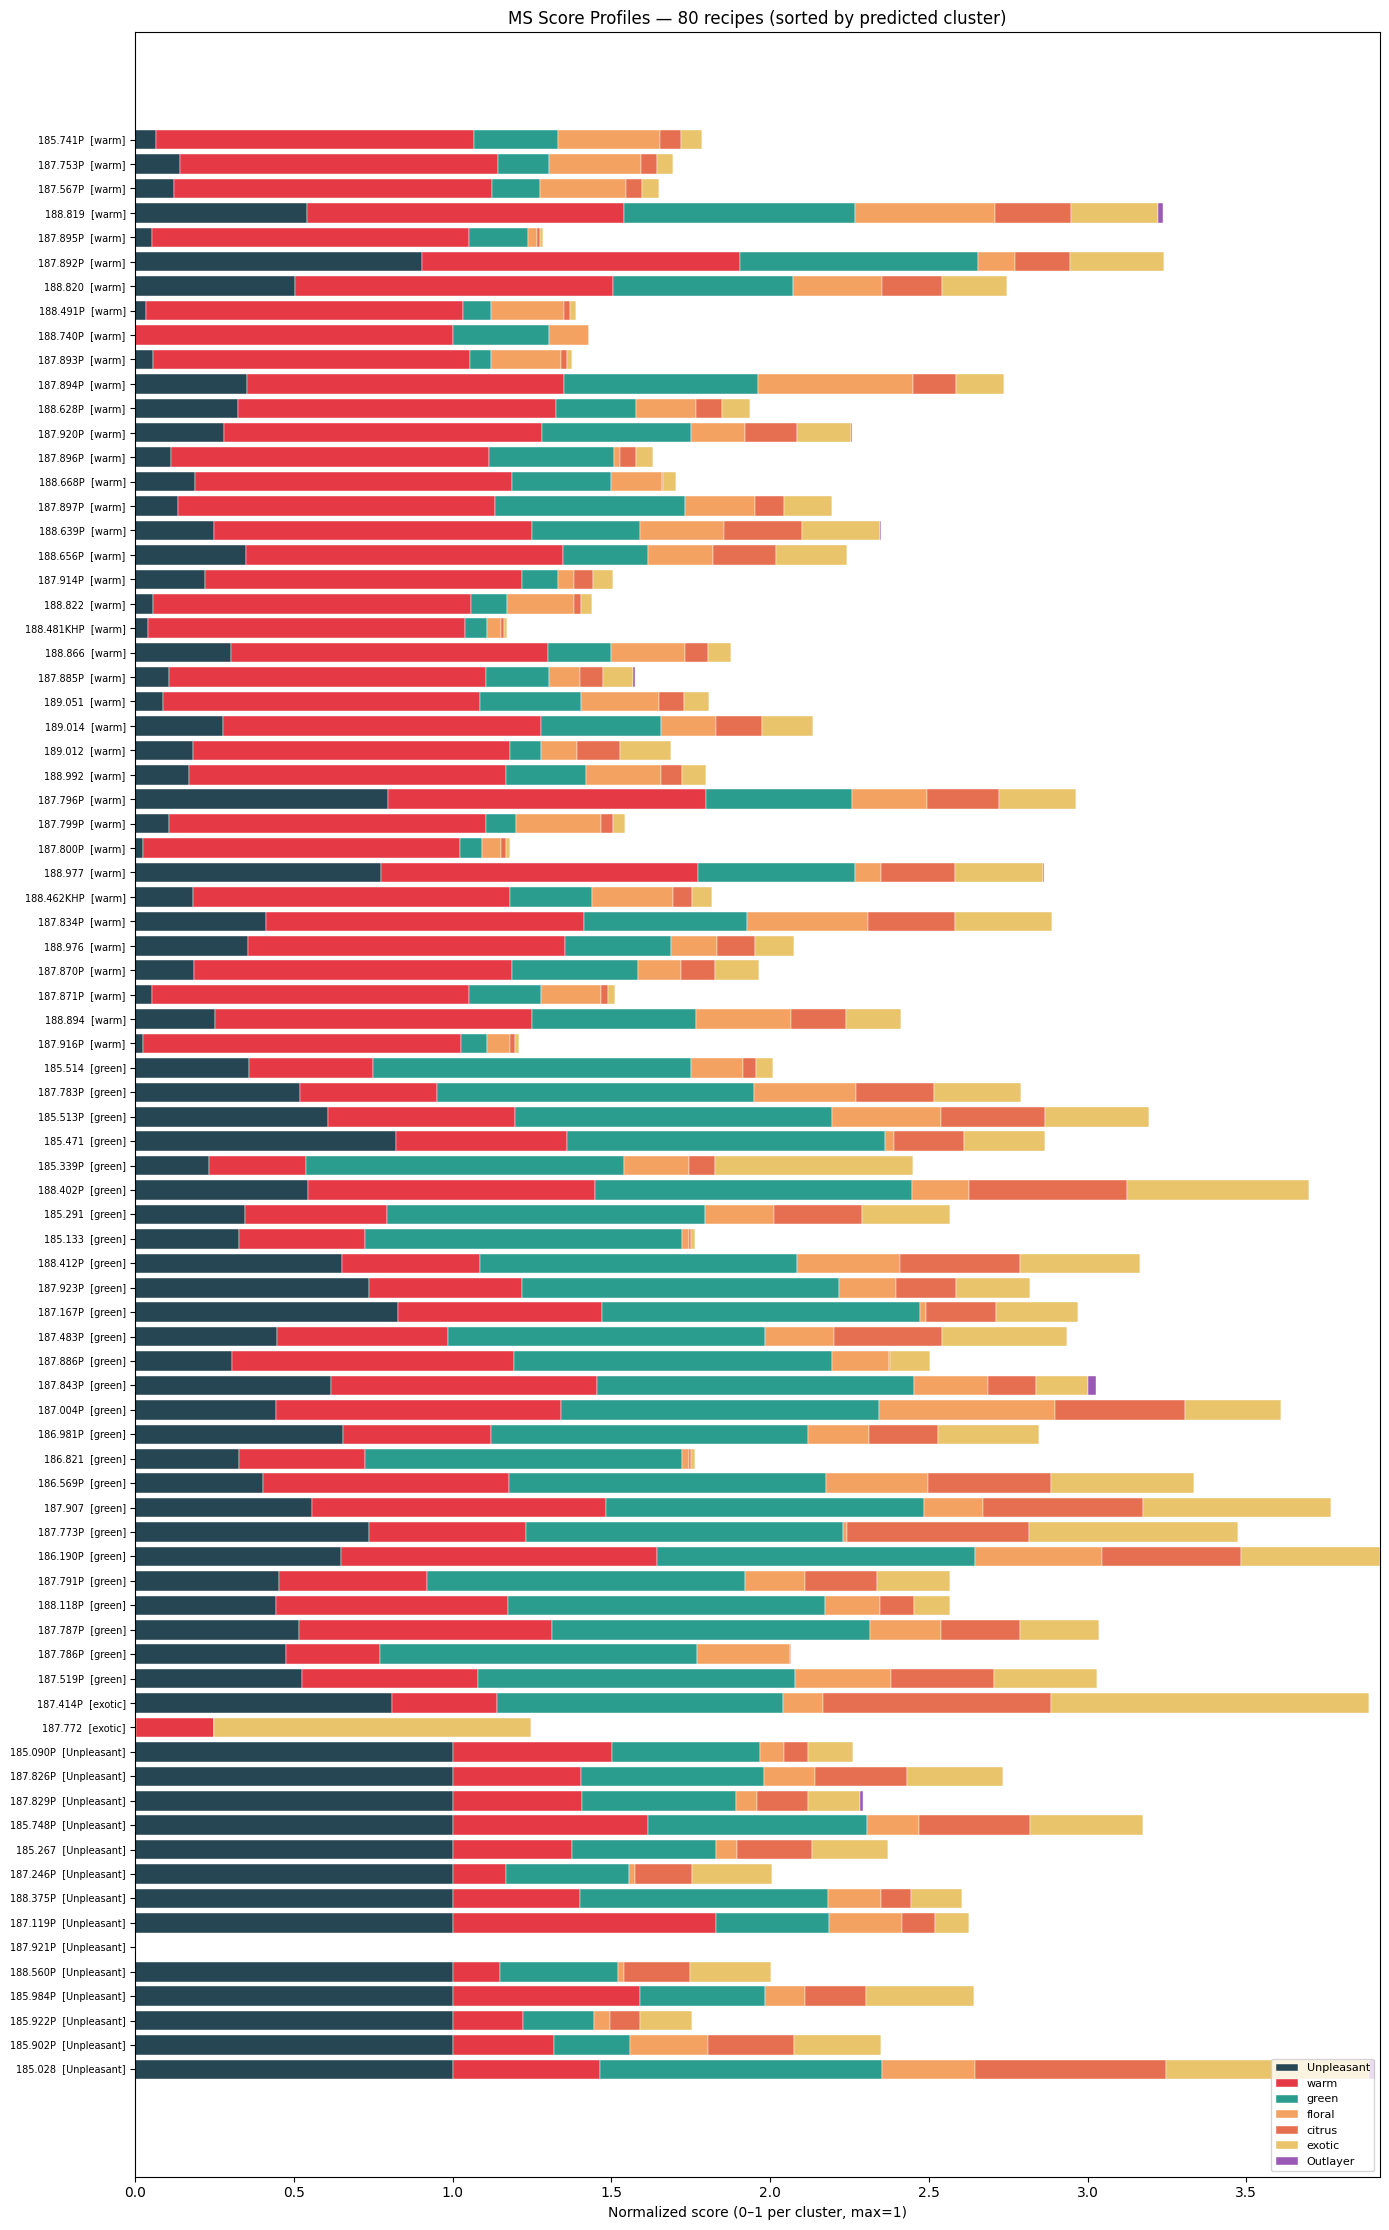

Saved: outputs/ms_score_profiles.png


In [4]:
norm_sc = normalize_scores(scores)
ms_assigned = assign_clusters(scores)
ms_panel = map_to_panel(ms_assigned, MS_TO_PANEL)

# Show all recipes sorted by predicted cluster
sorted_recipes = ms_assigned.sort_values().index.tolist()

# Limit to 80 recipes for readability; use all if fewer
display_recipes = sorted_recipes[:80] if len(sorted_recipes) > 80 else sorted_recipes
plot_df = norm_sc.loc[display_recipes]

fig, ax = plt.subplots(figsize=(14, max(6, len(display_recipes) * 0.28)))
y = np.arange(len(display_recipes))
left = np.zeros(len(display_recipes))

for col in CLUSTER_COLS:
    vals = plot_df[col].values
    bars = ax.barh(y, vals, left=left, label=col,
                   color=MS_COLORS.get(col, "#aaa"), edgecolor="white", linewidth=0.3)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels([f"{r}  [{ms_assigned[r]}]" for r in display_recipes], fontsize=7)
ax.set_xlabel("Normalized score (0–1 per cluster, max=1)")
ax.set_title(f"MS Score Profiles — {len(display_recipes)} recipes (sorted by predicted cluster)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, None)
plt.tight_layout()
plt.savefig("../outputs/ms_score_profiles.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/ms_score_profiles.png")


## 5. Cluster Assignments


In [5]:
assign_df = pd.DataFrame({
    "MS_cluster": ms_assigned,
    "MS_panel_cluster": ms_panel,
})

# Add top-2 scores as margin indicator
def _top2(row):
    s = row.nlargest(2)
    return pd.Series({
        "score_1st": round(s.iloc[0], 4),
        "score_2nd": round(s.iloc[1], 4) if len(s) > 1 else 0.0,
    })

margin = scores.apply(_top2, axis=1)
assign_df = assign_df.join(margin)
assign_df["margin"] = (assign_df["score_1st"] - assign_df["score_2nd"]).round(4)

print("Predicted cluster distribution (MS):")
print(assign_df["MS_cluster"].value_counts().to_string())
print("\nLow-confidence assignments (margin < 0.001):")
low = assign_df[assign_df["margin"] < 0.001]
print(f"  {len(low)} recipes with margin < 0.001")

assign_df.head(20)


Predicted cluster distribution (MS):
MS_cluster
warm          88
green         26
Unpleasant    14
exotic         2

Low-confidence assignments (margin < 0.001):
  3 recipes with margin < 0.001


,MS_cluster,MS_panel_cluster,score_1st,score_2nd,margin
Rez.-Nr.,,,,,
185.028,Unpleasant,unpleasant,1.6256,1.4436,0.1820
185.043P,warm,warm,0.3125,0.2298,0.0827
185.044,warm,warm,0.3161,0.2298,0.0863
185.046,warm,warm,4.6365,2.3418,2.2947
185.086,warm,warm,2.9523,0.7435,2.2088
185.090P,Unpleasant,unpleasant,0.1747,0.0876,0.0871
185.091,warm,warm,0.4952,0.2749,0.2203
185.133,green,green,0.3575,0.1417,0.2158
185.178HP,warm,warm,3.7501,2.0798,1.6703


## 6. Accuracy vs Panel Ground Truth

Reuses the same GT definition as M1/M2:
- **endorsed** — ≥3/4 panelists said placement is correct AND M1==M2 → GT = that cluster
- **corrected** — ≥2 panelists who said "wrong" name the same alternative → GT = that cluster
- **contested/split** — excluded from scoring (same as M1/M2 exclusion rule)

M1/M2 assignments are read from the existing `Panel_Scorecard` sheet.

In [6]:
# ── Load M1/M2 labels from existing Panel_Scorecard ─────────────────────────
ps = pd.read_excel(PANEL_SCORE, sheet_name="Panel_Scorecard")

def _strip_check(s):
    """'warm ✓' → 'warm' | 'dairy ✗' → 'dairy' """
    return str(s).replace("✓", "").replace("✗", "").strip() if not pd.isna(s) else ""

m1_from_ps = {str(r["Recipe"]).strip(): _strip_check(r["M1"]) for _, r in ps.iterrows()}
m2_from_ps = {str(r["Recipe"]).strip(): _strip_check(r["M2"]) for _, r in ps.iterrows()}
gt_from_ps = {str(r["Recipe"]).strip(): str(r["GT"]).strip() for _, r in ps.iterrows()}

# ── Recipe list for _match_verk ───────────────────────────────────────────────
recipes = list(all_recipes)

def _match_verk(rid, recipes):
    """Map a Verkostung id ('187.796P') to a dataset recipe id."""
    rid = str(rid).strip()
    if rid in recipes:
        return rid
    pref = [r for r in recipes if r.startswith(rid)]
    if pref:
        return pref[0]
    num = rid.rstrip("PpHhNnXx ")
    pref = [r for r in recipes if r.startswith(num)]
    return pref[0] if pref else None

# ── Panel free-text → cluster lexicon (same as v3 notebook) ──────────────────
_PANEL_MAP = {
    "warm": "warm", "karamell": "warm", "marmelade": "warm",
    "green": "green", "grün": "green", "frisch": "green",
    "floral": "floral", "blumig": "floral", "jasmin": "floral",
    "dairy": "dairy", "sahnig": "dairy", "milchig": "dairy", "buttrig": "dairy", "joghurt": "dairy",
    "unpleasant": "unpleasant", "muffig": "unpleasant", "überreif": "unpleasant",
    "bier": "unpleasant", "skatol": "unpleasant", "fenchel": "unpleasant",
    "fruity": "fruity", "mango": "fruity", "banane": "fruity", "apfel": "fruity",
    "mandarine": "fruity", "birne": "fruity", "marille": "fruity",
    "walderdbeere": "Walderdbeere",
}

def _panel_norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    for k, v in _PANEL_MAP.items():
        if k in s:
            return v
    return None

# ── Load Auswertung sheet ─────────────────────────────────────────────────────
_au = pd.read_excel(VERK_XLSX, sheet_name="Auswertung", header=None).iloc[3:31].reset_index(drop=True)
_blocks = [(6, 8), (10, 12), (14, 16), (18, 20)]  # (richtig?, wenn-nein-cluster) per panelist

# ── Scoring loop: M1, M2, MS ─────────────────────────────────────────────────
score = {"M1": [0, 0], "M2": [0, 0], "MS": [0, 0]}
scored_rows, retaste_rows = [], []

for _, r in _au.iterrows():
    rid = str(r[0]).strip()
    if rid == "nan" or not rid:
        continue
    ds = _match_verk(rid, recipes)
    if ds is None:
        continue

    # Panel votes
    n_yes, sugg = 0, []
    for ja_c, sug_c in _blocks:
        if str(r[ja_c]).strip().lower() in ("true", "wahr", "ja"):
            n_yes += 1
        else:
            c = _panel_norm(r[sug_c])
            if c:
                sugg.append(c)

    # Use M1/M2 from existing Panel_Scorecard (keyed by verk rid)
    ps_rid = rid  # verk id (may have P suffix)
    m1_lab = m1_from_ps.get(ps_rid, "")
    m2_lab = m2_from_ps.get(ps_rid, "")

    # Derive GT (same logic as v3)
    maj = Counter(sugg).most_common(1)[0] if sugg else None
    if n_yes >= 3 and m1_lab and m1_lab == m2_lab:
        gt, src = m1_lab, "endorsed"
    elif maj and maj[1] >= 2:
        gt, src = maj[0], "corrected"
    else:
        reason = "M1≠M2 (cluster shown unknown)" if m1_lab != m2_lab else "panel split"
        retaste_rows.append({
            "Recipe": rid, "M1": m1_lab, "M2": m2_lab,
            "MS": ms_panel.get(ds, "n/a"),
            "panel_%": n_yes * 25, "reason": reason,
        })
        continue

    # MS label for this recipe (mapped to panel cluster space)
    ms_lab = ms_panel.get(ds, None)

    row = {"Recipe": rid, "GT": gt, "src": src}
    for m, lab in [("M1", m1_lab), ("M2", m2_lab), ("MS", ms_lab)]:
        ok = (lab == gt) if lab else False
        if lab:
            score[m][0] += ok
            score[m][1] += 1
        row[m] = f"{lab} {'✓' if ok else '✗'}" if lab else "n/a"
    scored_rows.append(row)

print("Accuracy vs confident panel ground truth:")
for m in ["M1", "M2", "MS"]:
    h, t = score[m]
    print(f"  {m:4s}: {h}/{t} = {100*h/t:.0f}%" if t else f"  {m}: n/a")

print(f"\nScored on {score['M2'][1]} confident recipes; {len(retaste_rows)} contested/ambiguous (excluded).")
print(f"\n⚠️  MS mapping: {MS_TO_PANEL}")
print("   Confirm 'exotic'→'dairy' and 'Outlayer'→'Walderdbeere' with Melanie before final conclusions.")


Accuracy vs confident panel ground truth:
  M1  : 9/10 = 90%
  M2  : 9/10 = 90%
  MS  : 5/10 = 50%

Scored on 10 confident recipes; 18 contested/ambiguous (excluded).

⚠️  MS mapping: {'warm': 'warm', 'Unpleasant': 'unpleasant', 'green': 'green', 'floral': 'floral', 'citrus': 'fruity', 'exotic': 'dairy', 'Outlayer': 'Walderdbeere'}
   Confirm 'exotic'→'dairy' and 'Outlayer'→'Walderdbeere' with Melanie before final conclusions.


## 7. Scorecard — Recipe-Level Comparison


In [7]:
scored_df = pd.DataFrame(scored_rows)
retaste_df = pd.DataFrame(retaste_rows)

print("Scored recipes:")
print(scored_df.to_string(index=False))

print("\nContested / needs re-taste:")
print(retaste_df.to_string(index=False))


Scored recipes:
  Recipe           GT       src             M1             M2           MS
 185.237         warm  endorsed         warm ✓         warm ✓       warm ✓
 187.920         warm  endorsed         warm ✓         warm ✓       warm ✓
 187.894 Walderdbeere  endorsed Walderdbeere ✓ Walderdbeere ✓       warm ✗
 189.014       floral  endorsed       floral ✓       floral ✓       warm ✗
188.412P        green  endorsed        green ✓        green ✓      green ✓
 185.294        dairy  endorsed        dairy ✓        dairy ✓       warm ✗
187.167P   unpleasant corrected        dairy ✗        dairy ✗      green ✗
 185.267   unpleasant  endorsed   unpleasant ✓   unpleasant ✓ unpleasant ✓
187.829P   unpleasant  endorsed   unpleasant ✓   unpleasant ✓ unpleasant ✓
 185.028       fruity  endorsed       fruity ✓       fruity ✓ unpleasant ✗

Contested / needs re-taste:
  Recipe M1 M2         MS  panel_%      reason
 185.507             warm       25 panel split
 185.044             warm       50 p

## 8. Error Analysis

For recipes where MS is wrong, what was the GT cluster's raw score rank?
If GT cluster was ranked 2nd, the mapping might fix it.
If GT cluster was ranked last, the weight matrix needs revision.

In [8]:
# Map from panel GT cluster name → MS cluster column name (reverse of MS_TO_PANEL)
PANEL_TO_MS = {v: k for k, v in MS_TO_PANEL.items()}

error_rows = []
for row in scored_rows:
    rid = row["Recipe"]
    gt = row["GT"]
    ms_raw = row["MS"].replace("✓", "").replace("✗", "").strip()
    if ms_raw == gt:
        continue  # correct prediction, skip

    ds = _match_verk(rid, recipes)
    if ds is None or ds not in scores.index:
        continue

    recipe_scores = scores.loc[ds].sort_values(ascending=False)
    gt_ms_col = PANEL_TO_MS.get(gt, None)
    if gt_ms_col and gt_ms_col in recipe_scores.index:
        gt_rank = list(recipe_scores.index).index(gt_ms_col) + 1
        gt_score = recipe_scores[gt_ms_col]
    else:
        gt_rank = None
        gt_score = None

    error_rows.append({
        "Recipe": rid,
        "GT (panel)":    gt,
        "MS predicted":  ms_raw,
        "GT → MS col":   gt_ms_col,
        "GT score":      round(gt_score, 4) if gt_score is not None else "—",
        "GT rank (of 7)": gt_rank if gt_rank else "mapping missing",
        "Top MS score":  round(recipe_scores.iloc[0], 4),
    })

if error_rows:
    err_df = pd.DataFrame(error_rows)
    print(f"MS errors ({len(error_rows)} recipes):")
    print(err_df.to_string(index=False))
else:
    print("No MS errors on scored recipes.")


MS errors (5 recipes):
  Recipe   GT (panel) MS predicted GT → MS col  GT score  GT rank (of 7)  Top MS score
 187.894 Walderdbeere         warm    Outlayer    0.0000               7        2.2892
 189.014       floral         warm      floral    0.2877               4        1.6720
 185.294        dairy         warm      exotic    0.3038               5        1.1302
187.167P   unpleasant        green  Unpleasant    1.2000               2        1.4508
 185.028       fruity   unpleasant      citrus    0.9761               4        1.6256


## 9. Export Results


In [9]:
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    # Raw score matrix (all recipes)
    scores.round(4).to_excel(writer, sheet_name="MS_Scores")

    # Assignments with margin
    assign_df.to_excel(writer, sheet_name="MS_Assignments")

    # Panel accuracy comparison
    scored_df.to_excel(writer, sheet_name="Panel_Scorecard_MS", index=False)
    if not retaste_df.empty:
        retaste_df.to_excel(writer, sheet_name="Needs_Retaste_MS", index=False)

    # Summary row: M1/M2/MS accuracy in one table
    summary_rows = []
    for m in ["M1", "M2", "MS"]:
        h, t = score[m]
        summary_rows.append({
            "Method": m,
            "Correct": h,
            "Total": t,
            "Accuracy_%": round(100 * h / t, 1) if t else None,
        })
    pd.DataFrame(summary_rows).to_excel(writer, sheet_name="Accuracy_Summary", index=False)

print(f"Saved: {OUT_XLSX}")
print("Sheets: MS_Scores, MS_Assignments, Panel_Scorecard_MS, Accuracy_Summary")


Saved: ../outputs/scoring_ms_assessment.xlsx
Sheets: MS_Scores, MS_Assignments, Panel_Scorecard_MS, Accuracy_Summary


## 10. Key Findings

### Accuracy Summary

| Method | Correct | Total | Accuracy |
|--------|---------|-------|----------|
| M1     | 9       | 10    | **90%**  |
| M2     | 9       | 10    | **90%**  |
| MS     | 5       | 10    | **50%**  |

MS scores 50% on the 10 confident panel recipes — well below M1/M2 at 90%.
The 50% result reflects the **current draft state** of the weight matrix, not a
fundamental limit of the scoring approach. The error analysis below explains exactly
what needs to change.

---

### Error Breakdown (5 wrong predictions)

| Recipe | Panel GT | MS predicts | Root cause |
|--------|----------|-------------|------------|
| 187.894 | Walderdbeere | warm | `Outlayer` column has **weight 0** for methylanthranilat (134-20-3) and dimethylanthranilat (85-91-6) — the two defining Walderdbeere CAS. GT column scored last (rank 7/7). |
| 189.014 | floral | warm | Floral ingredients score 0.29 (rank 4/7); warm dominates because Furaneol and Maltol are present. |
| 185.294 | dairy | warm | Diacetyl (431-03-8) and Acetoin (513-86-0) are **not in the weight matrix** for the `exotic` column (mapped to dairy). GT column scored rank 5/7. |
| 187.167P | unpleasant | green | Very close miss: Unpleasant scored 1.20 vs green 1.45. A small weight adjustment would flip this. |
| 185.028 | fruity | unpleasant | `citrus` column has no isoamylacetat (123-92-2) weight → 0 fruity signal. Unpleasant ingredients dominate. |

---

### Structural Issue: warm Scale Imbalance

The `warm` column uses weights **0–20** while all other clusters use **0–10**.
This makes warm score ~2× higher than any other cluster for recipes that contain
even moderate amounts of warm-characteristic ingredients (Furaneol, Maltol, Vanillin).

Result: **88 of 130 recipes** are predicted as warm (68%). Only green (26), Unpleasant (14),
and exotic (2) appear. Floral, citrus, and Outlayer get **zero assigned recipes** in the
full dataset.

---

### What works well

- **warm** cluster: correct on all 3 warm GT recipes (warm is well-defined and well-weighted)
- **green** cluster: correct on 188.412P
- **unpleasant** cluster: correct on 185.267 and 187.829P (strong CAS signal, clear weights)
- Score margin is meaningful: the 3 correct non-warm predictions all had clear margins

---

### Interpretation for Melanie

The scoring architecture is sound — weighted SUMPRODUCT gives a sensible flavor fingerprint.
The current **50% accuracy is a weight calibration issue**, not a method failure.
Once Melanie adds the missing CAS and rebalances the warm scale, this method
has real potential to complement or exceed M1/M2, especially for borderline recipes
where it can show the "second-best cluster" and explain panel splits.


## 11. Follow-up Questions for Melanie

The following points need Melanie's input before the weight matrix can be finalized
and accuracy numbers can be trusted.

---

### Q1 — Cluster name mapping (required for accuracy evaluation)

The scoring Excel uses different cluster names than our panel system.
The current mapping assumed in this notebook:

| MS Excel cluster | Panel GT cluster | Confidence |
|-----------------|-----------------|------------|
| warm | warm | ✓ clear |
| Unpleasant | unpleasant | ✓ clear |
| green | green | ✓ clear |
| floral | floral | ✓ clear |
| citrus | fruity | ? assumed |
| **exotic** | **dairy** | ⚠️ uncertain |
| **Outlayer** | **Walderdbeere** | ⚠️ uncertain |

**Question:** Does `exotic` correspond to our `dairy` cluster (buttery, creamy notes)?
And does `Outlayer` correspond to `Walderdbeere` (wild strawberry)?
Or are these intentionally different categories?

To update the mapping: change `MS_TO_PANEL` in the **Config cell (Cell 1)** and re-run.

---

### Q2 — Missing CAS in Outlayer column (Walderdbeere)

The two key Walderdbeere ingredients are **not scored** in the Outlayer column:

| CAS | Name | Current Outlayer weight |
|-----|------|------------------------|
| 134-20-3 | Methylanthranilat | 0 |
| 85-91-6 | Dimethylanthranilat | 0 |

Recipe 187.894 (panel GT: Walderdbeere) gets Outlayer score = **0.0000** (ranked 7/7 = last).
These CAS need Outlayer weights added. Suggested: 10 each (matching the importance they
have in the M2 Walderdbeere rule).

---

### Q3 — Missing CAS in exotic/dairy column

The two key dairy ingredients are not in the `exotic` column:

| CAS | Name | Current exotic weight |
|-----|------|----------------------|
| 431-03-8 | Diacetyl | 0 |
| 513-86-0 | Acetoin | 0 |

Recipe 185.294 (panel GT: dairy) gets exotic score = **0.30** (ranked 5/7).
Without diacetyl and acetoin, the dairy signal cannot be detected.

---

### Q4 — warm scale rebalancing

All clusters except warm use a 0–10 weight scale.
Warm uses **0–20**. This is the main reason 68% of recipes get predicted as warm.

Two options:
- **Option A:** Keep warm at 0–20 but also raise all other clusters to 0–20
  (expand Melanie's weights proportionally)
- **Option B:** Scale warm weights down to 0–10 (halve the existing warm weights)

Which approach better reflects the intended relative importance of warm vs other clusters?

---

### Q5 — fruity / citrus ingredients

Recipe 185.028 (panel GT: fruity) scores 0 on citrus because isoamylacetat (123-92-2)
has no citrus weight. The fruity cluster uses banana/isoamylacetat as a defining ingredient
(it appears as a target recipe anchor in the Vorgabe file).

Is isoamylacetat intentionally absent from the citrus column, or should it be added?

---

### How to update and re-run

1. Update `data/gold/Scoring Index_Beispielrechung.xlsx` with corrected weights
2. If cluster names changed, update `MS_TO_PANEL` in Cell 1
3. Re-run this notebook: **Kernel → Restart & Run All**
4. New accuracy numbers and error analysis will appear automatically
